# Decision Transformer: HalfCheetah Offline Policy Training

**Project:** Eliminating the High-Risk Interaction Cost of Autonomous Robotics through Offline Sequence Modeling: A Decision Transformer Approach  
**Authors:** Darwin Juan, Dan Kast, David Terando  
**Date:** April 2026

---

## Notebook Overview

This notebook implements the full Decision Transformer (DT) pipeline on the Minari HalfCheetah datasets validated during EDA. The pipeline has five stages:

| Section | Description |
|---------|-------------|
| **0** | Global Configuration — all tunable hyperparameters in one place |
| **1** | Environment & Dependency Setup |
| **2** | Data Loading & Preprocessing — Minari → RTG-annotated trajectory buffer |
| **3** | Decision Transformer Architecture — GPT-2 backbone from scratch |
| **4** | Training Loop — with HardwareTracker (BPS, wall-clock, GPU/MPS/CPU stats) |
| **5** | Offline Policy Evaluation — MuJoCo rollouts with RTG conditioning |

**Hardware targets:** M5 Max MacBook Pro (MPS), M1 iMac (MPS), Cloud GPU (CUDA)  
**Dataset:** `mujoco/halfcheetah/medium-v0` + `mujoco/halfcheetah/expert-v0` (Minari Combined)  
**Architecture:** GPT-2 backbone, built from scratch with HuggingFace `transformers`

---

> **Reproducibility note:** All random seeds are set in Section 0. Run cells top-to-bottom for a fully reproducible run.

---
## Section 0: Global Configuration

All hyperparameters, paths, and toggles are defined here as a single `CFG` dataclass.  
**Edit this cell — not the code below — when tuning or switching hardware.**

In [1]:
from dataclasses import dataclass, field
from typing import Optional

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIGURATION
# All tunable values live here. Sections below read from CFG — never hardcode.
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class Config:

    # ── Reproducibility ───────────────────────────────────────────────────────
    seed: int = 42

    # ── Dataset ───────────────────────────────────────────────────────────────
    minari_medium_id: str  = 'mujoco/halfcheetah/medium-v0'
    minari_expert_id: str  = 'mujoco/halfcheetah/expert-v0'

    # ── MuJoCo environment ────────────────────────────────────────────────────
    # 'HalfCheetah-v4' is the current Gymnasium API (recommended).
    # Switch to 'HalfCheetah-v2' to reproduce the original DT paper exactly.
    mujoco_env_id: str     = 'HalfCheetah-v4'

    # ── State / action dimensions (fixed by HalfCheetah) ─────────────────────
    state_dim: int         = 17
    action_dim: int        = 6
    max_ep_len: int        = 1000   # all HalfCheetah episodes are exactly 1000 steps

    # ── Context window ────────────────────────────────────────────────────────
    # K = number of (RTG, state, action) triplets the transformer sees at once.
    # Original DT paper uses K=20 for HalfCheetah; increase for richer context.
    context_len: int       = 20     # K in the paper

    # ── Transformer architecture ──────────────────────────────────────────────
    # These match the 'small' DT config from the original paper.
    hidden_dim: int        = 128    # embedding / hidden size (n_embd)
    n_layers: int          = 3      # number of transformer blocks
    n_heads: int           = 1      # attention heads
    dropout: float         = 0.1    # residual dropout

    # ── Training ──────────────────────────────────────────────────────────────
    # batch_size: tuned for M5 Max 128 GB unified memory.
    # The full dataset is ~176 MB; even a batch of 512 × K=20 windows
    # occupies < 10 MB on-device, so memory is not the bottleneck here.
    # 256 saturates MPS throughput well; increase to 512 if BPS plateaus.
    batch_size: int        = 64
    learning_rate: float   = 1e-4
    weight_decay: float    = 1e-4
    warmup_steps: int      = 10_000
    grad_clip: float       = 0.25   # max gradient norm

    # Quick-validation run: a small number of iterations to verify the pipeline
    # works end-to-end before committing to the full run.
    quick_val_iters: int   = 500    # ~minutes on M5 Max

    # Full training run: matches the DT paper's 100k gradient steps.
    full_train_iters: int  = 100_000

    # Set to True to run quick validation first, then ask before full run.
    run_quick_val_first: bool = True

    # ── RTG normalization ─────────────────────────────────────────────────────
    # Scale factor applied to raw RTG values before feeding to the model.
    # Keeps RTG inputs in a numerically stable range (~0-1).
    # Set to max episode return observed in the combined Minari dataset (EDA §10).
    rtg_scale: float       = 16_585.0

    # Target RTG used during MuJoCo inference rollouts (also from EDA §10).
    target_rtg: float      = 16_585.0

    # ── Evaluation ────────────────────────────────────────────────────────────
    eval_episodes: int     = 10     # number of MuJoCo rollout episodes per eval
    eval_every_n_iters: int = 5_000 # run eval this often during full training

    # ── Checkpointing & outputs ───────────────────────────────────────────────
    checkpoint_dir: str    = './checkpoints'
    results_dir: str       = './results'
    save_every_n_iters: int = 10_000  # save checkpoint this often

    # ── Hardware ──────────────────────────────────────────────────────────────
    # Leave as None to auto-detect (cuda > mps > cpu).
    # Override with 'cuda', 'mps', or 'cpu' to force a specific backend.
    force_device: Optional[str] = None

    # Human-readable label for the hardware tracker logs (used in CSVs / plots).
    # Change this when running on different machines for comparison.
    hardware_label: str    = 'M5-Max-Standard'  # e.g. 'M1-iMac', 'Lambda-A100'

    # ── Memory strategy ───────────────────────────────────────────────────────
    # With 128 GB unified memory on the M5 Max, the entire preprocessed dataset
    # (~176 MB for 2M timesteps) is pinned in RAM as pre-built PyTorch tensors.
    # This eliminates per-batch numpy slicing and tensor allocation overhead,
    # and is the primary reason BPS is substantially higher on this machine
    # than on memory-constrained platforms.
    #
    # Set to False on machines with < 8 GB RAM to fall back to the standard
    # on-the-fly episode sampling path (slower but memory-safe).
    preload_to_ram: bool   = False


# Instantiate the global config object used throughout the notebook
CFG = Config()

print("=" * 60)
print("  Decision Transformer — Global Configuration")
print("=" * 60)
for k, v in CFG.__dict__.items():
    print(f"  {k:<26} = {v}")
print("=" * 60)


  Decision Transformer — Global Configuration
  seed                       = 42
  minari_medium_id           = mujoco/halfcheetah/medium-v0
  minari_expert_id           = mujoco/halfcheetah/expert-v0
  mujoco_env_id              = HalfCheetah-v4
  state_dim                  = 17
  action_dim                 = 6
  max_ep_len                 = 1000
  context_len                = 20
  hidden_dim                 = 128
  n_layers                   = 3
  n_heads                    = 1
  dropout                    = 0.1
  batch_size                 = 64
  learning_rate              = 0.0001
  weight_decay               = 0.0001
  warmup_steps               = 10000
  grad_clip                  = 0.25
  quick_val_iters            = 500
  full_train_iters           = 100000
  run_quick_val_first        = True
  rtg_scale                  = 16585.0
  target_rtg                 = 16585.0
  eval_episodes              = 10
  eval_every_n_iters         = 5000
  checkpoint_dir             = ./checkpoi

---
## Section 1: Environment Setup & Imports

### 1.1 Dependency Installation

This project uses **uv** for package management. Run the cell below once per environment to install all required packages.

**Expected install command (run in terminal, not here):**
```bash
uv pip install torch torchvision \
    transformers \
    minari[hf] \
    gymnasium[mujoco] \
    mujoco \
    numpy pandas matplotlib seaborn tqdm psutil
```

> **Apple Silicon note (M5 Max / M1 iMac):** PyTorch ships with native MPS support for arm64. No separate CUDA toolkit needed. Install with `uv pip install torch` — the arm64 wheel includes MPS automatically.  
> **Cloud GPU (CUDA):** Install with `uv pip install torch --index-url https://download.pytorch.org/whl/cu121`

### 1.2 Known Issues from EDA (pre-resolved)
- `minari` requires `[hf]` extras: `uv pip install "minari[hf]"`
- Minari dataset IDs use namespaced format: `mujoco/halfcheetah/medium-v0` (not `halfcheetah-medium-v0`)
- `pandas >= 3.x`: use `.map()` not `.applymap()` — already handled below
- `d4rl` package is NOT used — all data comes from Minari

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Imports, Seed, and Device Detection
# ─────────────────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import os
import sys
import time
import json
import random
import platform
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import GPT2Config, GPT2Model

import minari
import gymnasium as gym

# ── Output directories ────────────────────────────────────────────────────────
Path(CFG.checkpoint_dir).mkdir(parents=True, exist_ok=True)
Path(CFG.results_dir).mkdir(parents=True, exist_ok=True)

# ── Global random seed ────────────────────────────────────────────────────────
# Setting seeds in all relevant libraries ensures reproducibility across runs.
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG.seed)

# ── Device selection ──────────────────────────────────────────────────────────
# Priority: user override > CUDA (NVIDIA GPU) > MPS (Apple Silicon) > CPU
if CFG.force_device:
    DEVICE = torch.device(CFG.force_device)
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

# ── Environment summary ───────────────────────────────────────────────────────
print("=" * 60)
print("  Environment Summary")
print("=" * 60)
print(f"  Python          : {sys.version.split()[0]}")
print(f"  PyTorch         : {torch.__version__}")
print(f"  Device selected : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU             : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif DEVICE.type == 'mps':
    print(f"  Backend         : Apple Metal Performance Shaders (MPS)")
print(f"  Platform        : {platform.processor()} | {platform.machine()}")
print(f"  System RAM      : {psutil.virtual_memory().total / 1e9:.1f} GB")
print(f"  Hardware label  : {CFG.hardware_label}")
print("=" * 60)

  Environment Summary
  Python          : 3.11.15
  PyTorch         : 2.11.0
  Device selected : mps
  Backend         : Apple Metal Performance Shaders (MPS)
  Platform        : arm | arm64
  System RAM      : 137.4 GB
  Hardware label  : M5-Max-Standard


---
## Section 2: Data Loading & Preprocessing

### Pipeline Overview

```
Minari medium-v0  ┐
                  ├─► Combined Episodes ─► RTG Annotation ─► State Normalization ─► SequenceDataset
Minari expert-v0  ┘
```

Three critical preprocessing steps:
1. **RTG Annotation** — for each timestep `t`, RTG[t] = Σ rewards[t:end]. This is the conditioning signal the DT receives.
2. **State Normalization** — subtract mean and divide by std computed across the *entire combined dataset*. This is essential for stable training (per the original DT paper).
3. **Context-Window Slicing** — each training sample is a fixed-length window of K (RTG, state, action) triplets, with zero-padding and an attention mask for short windows.

___
### SECTION 2.1: Load Minari Datasets

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.1: Load Minari Datasets
# Downloads on first call (requires internet); uses local cache on subsequent runs.
# ─────────────────────────────────────────────────────────────────────────────

def load_minari_to_episodes(dataset_id: str) -> List[Dict]:
    """
    Load a Minari dataset and return a list of episode dicts.

    Each episode dict has keys:
        observations : np.ndarray (T, state_dim)
        actions      : np.ndarray (T, action_dim)
        rewards      : np.ndarray (T,)
        terminals    : np.ndarray (T,)  — True on the last step of an episode

    Minari stores T+1 observations per episode (initial obs + one per step).
    We drop the final observation to align dimensions with actions/rewards.
    """
    print(f"  Loading: {dataset_id}")
    try:
        ds = minari.load_dataset(dataset_id)
    except Exception:
        print(f"    Not cached — downloading from Hugging Face...")
        minari.download_dataset(dataset_id)
        ds = minari.load_dataset(dataset_id)

    episodes = []
    for ep in tqdm(ds.iterate_episodes(),
                   total=ds.total_episodes,
                   desc=f"    Parsing {dataset_id.split('/')[-1]}",
                   leave=False):
        episodes.append({
            'observations': ep.observations[:-1].astype(np.float32),  # drop terminal obs
            'actions'     : ep.actions.astype(np.float32),
            'rewards'     : ep.rewards.astype(np.float32),
            'terminals'   : ep.terminations.astype(bool),
        })
    print(f"    Loaded {len(episodes):,} episodes, "
          f"{sum(len(e['rewards']) for e in episodes):,} timesteps")
    return episodes


print("Loading Minari datasets...")
episodes_medium = load_minari_to_episodes(CFG.minari_medium_id)
episodes_expert = load_minari_to_episodes(CFG.minari_expert_id)

# Combine into a single flat list of episodes (mirrors D4RL medium-expert structure)
all_episodes = episodes_medium + episodes_expert
print(f"\n  Combined: {len(all_episodes):,} episodes, "
      f"{sum(len(e['rewards']) for e in all_episodes):,} total timesteps")

Loading Minari datasets...
  Loading: mujoco/halfcheetah/medium-v0


    Loaded 1,000 episodes, 1,000,000 timesteps
  Loading: mujoco/halfcheetah/expert-v0


    Loaded 1,000 episodes, 1,000,000 timesteps

  Combined: 2,000 episodes, 2,000,000 total timesteps


___
### SECTION 2.2: RTG Annotation

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.2: RTG Annotation
#
# RTG[t] = Σ rewards[t : end_of_episode]
# This is computed once per episode and stored alongside observations/actions.
#
# Why: the Decision Transformer is conditioned on RTG at every step. During
# training, it sees the ground-truth RTG from the dataset. During inference,
# we set RTG to our target (e.g. 16,585) and decrement by the observed reward.
# ─────────────────────────────────────────────────────────────────────────────

def annotate_rtg(episodes: List[Dict]) -> List[Dict]:
    """Add an 'rtg' key to each episode dict (reverse cumulative sum of rewards)."""
    for ep in episodes:
        # np.cumsum on reversed array, then reverse back = reverse cumsum
        ep['rtg'] = np.cumsum(ep['rewards'][::-1])[::-1].astype(np.float32)
    return episodes

all_episodes = annotate_rtg(all_episodes)

# Sanity check: RTG[0] == total episode return
sample_ep = all_episodes[0]
print(f"RTG annotation check (episode 0):")
print(f"  RTG[0]                : {sample_ep['rtg'][0]:.2f}")
print(f"  sum(rewards)          : {sample_ep['rewards'].sum():.2f}  (should match)")
print(f"  RTG is monotone dec.  : {bool(np.all(np.diff(sample_ep['rtg']) <= 0))}")

RTG annotation check (episode 0):
  RTG[0]                : 13960.90
  sum(rewards)          : 13960.90  (should match)
  RTG is monotone dec.  : False


Note: A False in RTG is monotone needs investigation, it means at least one step had a negative or zero reward, causing RTG to stay flat or tick up momentarily. The following code and result shows the worst violation is a small positive number (e.g. < 1.0) and it’s probably just noise and training will be unaffected.

In [5]:
rtg = all_episodes[0]['rtg']
diffs = np.diff(rtg)
print(f"Non-decreasing steps : {(diffs > 0).sum()}")
print(f"Worst violation      : {diffs.max():.4f}")
print(f"Mean step reward     : {-diffs.mean():.4f}")


Non-decreasing steps : 4
Worst violation      : 0.9766
Mean step reward     : 13.9606


___
### SECTION 2.3: State Normalization

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.3: State Normalization
#
# Compute mean and std across the ENTIRE combined dataset (both splits).
# Normalize every episode's observations in-place.
#
# Why this matters: without normalization, high-variance dimensions (e.g.
# root_x velocity, which can be large) dominate the embedding space and
# destabilize early training. The DT paper reports this as critical.
# ─────────────────────────────────────────────────────────────────────────────

# Stack all observations from the combined dataset to compute global statistics
all_obs = np.concatenate([ep['observations'] for ep in all_episodes], axis=0)
STATE_MEAN = all_obs.mean(axis=0).astype(np.float32)  # shape: (state_dim,)
STATE_STD  = all_obs.std(axis=0).astype(np.float32)   # shape: (state_dim,)

# Guard against zero-std dimensions (avoid division by zero)
STATE_STD = np.maximum(STATE_STD, 1e-6)

# Apply normalization to each episode in-place
for ep in all_episodes:
    ep['observations'] = (ep['observations'] - STATE_MEAN) / STATE_STD

# Save normalization stats — we need them during MuJoCo inference
np.save(f"{CFG.results_dir}/state_mean.npy", STATE_MEAN)
np.save(f"{CFG.results_dir}/state_std.npy",  STATE_STD)

print(f"State normalization computed on {len(all_obs):,} timesteps.")
print(f"  state_mean saved to: {CFG.results_dir}/state_mean.npy")
print(f"  state_std  saved to: {CFG.results_dir}/state_std.npy")
print(f"\nPost-normalization check (should be ~0 mean, ~1 std):")
all_obs_norm = np.concatenate([ep['observations'] for ep in all_episodes], axis=0)
print(f"  Global mean range : [{all_obs_norm.mean(axis=0).min():.4f}, {all_obs_norm.mean(axis=0).max():.4f}]")
print(f"  Global std  range : [{all_obs_norm.std(axis=0).min():.4f}, {all_obs_norm.std(axis=0).max():.4f}]")
del all_obs, all_obs_norm  # free memory — 2M x 17 float32 ≈ 136 MB

State normalization computed on 2,000,000 timesteps.
  state_mean saved to: ./results/state_mean.npy
  state_std  saved to: ./results/state_std.npy

Post-normalization check (should be ~0 mean, ~1 std):
  Global mean range : [-0.0000, 0.0072]
  Global std  range : [0.9985, 1.0004]


___
### SECTION 2.4: SequenceDataset — Context-Window Slicing

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.4: SequenceDataset — Context-Window Slicing
#
# The DT is trained on fixed-length windows (K triplets) sampled uniformly
# from all positions in all episodes.
#
# M5 Max / 128 GB memory path (CFG.preload_to_ram = True):
#   The entire dataset is materialized as a single pre-stacked PyTorch tensor
#   in RAM at init time. __getitem__ then performs pure tensor indexing with
#   no numpy allocation per call — eliminating the main CPU bottleneck on
#   memory-rich machines. With 2M timesteps at float32 this costs ~176 MB.
#
# Standard path (CFG.preload_to_ram = False):
#   Episode-by-episode numpy slicing on every __getitem__ call. Slower but
#   safe on machines with limited RAM (e.g. M1 iMac with 16 GB).
#
# Both paths produce identical output tensors.
# ─────────────────────────────────────────────────────────────────────────────

class SequenceDataset(Dataset):
    """
    PyTorch Dataset that yields random K-length windows from the offline buffer.

    Each item is a dict of tensors with shape (K, dim):
        states      : (K, state_dim)    normalized observations
        actions     : (K, action_dim)
        rtg         : (K, 1)            scaled RTG values
        timesteps   : (K,)              absolute timestep index within episode
        mask        : (K,)              1 = real data, 0 = left-padding
    """

    def __init__(
        self,
        episodes    : List[Dict],
        context_len : int,
        rtg_scale   : float,
        preload     : bool = True,
    ):
        self.context_len = context_len
        self.rtg_scale   = rtg_scale
        self.preload     = preload

        # Build sampling weights proportional to episode length.
        lengths = np.array([len(ep['rewards']) for ep in episodes], dtype=np.int64)
        self.sample_weights  = (lengths / lengths.sum()).astype(np.float64)
        self.total_timesteps = int(lengths.sum())

        # ── Episode boundary index ─────────────────────────────────────────
        # For fast episode lookup: given a global timestep, which episode
        # does it belong to and at what local offset?
        # cumulative_ends[i] = index of the last timestep in episode i (exclusive)
        self.episode_lengths = lengths
        self.ep_starts = np.concatenate([[0], np.cumsum(lengths[:-1])])

        if preload:
            self._preload_to_ram(episodes)
        else:
            # Standard path: keep episodes as list of numpy arrays
            self.episodes = episodes

    def _preload_to_ram(self, episodes: List[Dict]):
        """
        Concatenate all episode data into contiguous PyTorch tensors.

        Memory layout (float32):
          states  : (total_T, state_dim)   ~  2M × 17 = ~136 MB
          actions : (total_T, action_dim)  ~  2M ×  6 =  ~48 MB
          rtg     : (total_T,)             ~  2M ×  1 =   ~8 MB
          tsteps  : (total_T,)             int32, ~8 MB
        Total: ~200 MB — trivial on 128 GB unified memory.
        """
        import sys
        print("  Pre-loading dataset into RAM (M5 Max / 128 GB path)...")

        states_list  = [ep['observations'] for ep in episodes]
        actions_list = [ep['actions']      for ep in episodes]
        rtg_list     = [ep['rtg']          for ep in episodes]
        tstep_list   = [np.arange(len(ep['rewards']), dtype=np.int32) for ep in episodes]

        # Single concatenation — much faster than incremental appends
        all_states  = np.concatenate(states_list,  axis=0)
        all_actions = np.concatenate(actions_list, axis=0)
        all_rtg     = np.concatenate(rtg_list,     axis=0)
        all_tsteps  = np.concatenate(tstep_list,   axis=0)

        # Store as PyTorch tensors — __getitem__ does pure tensor slicing
        self.t_states  = torch.from_numpy(all_states)                   # float32
        self.t_actions = torch.from_numpy(all_actions)                  # float32
        self.t_rtg     = torch.from_numpy(all_rtg / self.rtg_scale)     # float32, scaled
        self.t_tsteps  = torch.from_numpy(all_tsteps.astype(np.int64))  # int64 for embedding

        mem_mb = (self.t_states.nbytes + self.t_actions.nbytes +
                  self.t_rtg.nbytes + self.t_tsteps.nbytes) / 1e6
        print(f"  Dataset pinned in RAM: {mem_mb:.1f} MB")
        print(f"  RAM available after preload: "
              f"{(psutil.virtual_memory().available / 1e9):.1f} GB")

    def __len__(self):
        # Report total timesteps so one "epoch" nominally covers all data.
        return self.total_timesteps

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        # ── Step 1: Sample an episode (length-proportional) ────────────────
        ep_idx     = np.random.choice(len(self.episode_lengths), p=self.sample_weights)
        ep_len     = int(self.episode_lengths[ep_idx])
        ep_start   = int(self.ep_starts[ep_idx])

        # ── Step 2: Sample a random end-point within the episode ───────────
        t_local    = np.random.randint(0, ep_len)   # local offset within episode
        t_end_g    = ep_start + t_local             # global index in flat tensor
        t_start_l  = max(0, t_local - self.context_len + 1)
        t_start_g  = ep_start + t_start_l
        window_len = t_local - t_start_l + 1       # actual window length (<= K)
        pad        = self.context_len - window_len

        if self.preload:
            # ── Fast path: pure tensor slicing, zero copy ──────────────────
            sl = slice(t_start_g, t_end_g + 1)

            states_w  = self.t_states[sl]   # (window_len, state_dim)
            actions_w = self.t_actions[sl]  # (window_len, action_dim)
            rtg_w     = self.t_rtg[sl]      # (window_len,)
            tsteps_w  = self.t_tsteps[sl]   # (window_len,)

            if pad > 0:
                # Prepend zero padding using torch.cat (stays on CPU, no numpy)
                z_s = torch.zeros(pad, CFG.state_dim,  dtype=torch.float32)
                z_a = torch.zeros(pad, CFG.action_dim, dtype=torch.float32)
                z_r = torch.zeros(pad,                 dtype=torch.float32)
                z_t = torch.zeros(pad,                 dtype=torch.long)
                states_w  = torch.cat([z_s, states_w],  dim=0)
                actions_w = torch.cat([z_a, actions_w], dim=0)
                rtg_w     = torch.cat([z_r, rtg_w],     dim=0)
                tsteps_w  = torch.cat([z_t, tsteps_w],  dim=0)

            mask = torch.zeros(self.context_len, dtype=torch.float32)
            mask[pad:] = 1.0

            return {
                'states'   : states_w,
                'actions'  : actions_w,
                'rtg'      : rtg_w.unsqueeze(-1),   # (K, 1)
                'timesteps': tsteps_w,
                'mask'     : mask,
            }

        else:
            # ── Standard path: numpy slicing (memory-safe fallback) ────────
            ep = self.episodes[ep_idx]
            states  = ep['observations'][t_start_l : t_local + 1].copy()
            actions = ep['actions'][t_start_l      : t_local + 1].copy()
            rtg     = ep['rtg'][t_start_l          : t_local + 1] / self.rtg_scale
            tsteps  = np.arange(t_start_l, t_local + 1, dtype=np.int64)

            if pad > 0:
                states  = np.concatenate([np.zeros((pad, states.shape[1]),  np.float32), states])
                actions = np.concatenate([np.zeros((pad, actions.shape[1]), np.float32), actions])
                rtg     = np.concatenate([np.zeros(pad, np.float32), rtg])
                tsteps  = np.concatenate([np.zeros(pad, np.int64),   tsteps])

            mask = np.zeros(self.context_len, np.float32)
            mask[pad:] = 1.0

            return {
                'states'   : torch.tensor(states,         dtype=torch.float32),
                'actions'  : torch.tensor(actions,        dtype=torch.float32),
                'rtg'      : torch.tensor(rtg[:, None],   dtype=torch.float32),
                'timesteps': torch.tensor(tsteps,         dtype=torch.long),
                'mask'     : torch.tensor(mask,           dtype=torch.float32),
            }


# ── Instantiate dataset and dataloader ───────────────────────────────────────
dataset = SequenceDataset(
    episodes    = all_episodes,
    context_len = CFG.context_len,
    rtg_scale   = CFG.rtg_scale,
    preload     = CFG.preload_to_ram,
)

# DataLoader tuning for M5 Max:
#   num_workers=0  — MPS requires all tensor ops on the main process;
#                    worker processes cannot share MPS context.
#   pin_memory     — only beneficial for CUDA (PCIe DMA); no effect on MPS.
#   persistent_workers — irrelevant at num_workers=0.
#
# With the preloaded tensor buffer, the DataLoader's main bottleneck shifts
# from disk/numpy I/O to the MPS kernel dispatch latency, which is amortized
# by the larger batch size (256 vs 64).
dataloader = DataLoader(
    dataset,
    batch_size = CFG.batch_size,
    shuffle    = True,
    num_workers= 0,
    pin_memory = (DEVICE.type == 'cuda'),
    drop_last  = True,
)

# ── Dataset and memory summary ────────────────────────────────────────────────
ram_total = psutil.virtual_memory().total / 1e9
ram_used  = psutil.virtual_memory().used  / 1e9
print(f"SequenceDataset ready.")
print(f"  Preload mode      : {CFG.preload_to_ram} ({'fast tensor path' if CFG.preload_to_ram else 'standard numpy path'})")
print(f"  Total timesteps   : {dataset.total_timesteps:,}")
print(f"  Context window K  : {CFG.context_len}")
print(f"  Batch size        : {CFG.batch_size}")
print(f"  Steps per epoch   : ~{len(dataset) // CFG.batch_size:,}")
print(f"  RAM used / total  : {ram_used:.1f} GB / {ram_total:.1f} GB")

# Inspect one sample batch
sample_batch = next(iter(dataloader))
print(f"\nSample batch tensor shapes:")
for k, v in sample_batch.items():
    print(f"  {k:<12}: {tuple(v.shape)}")


SequenceDataset ready.
  Preload mode      : False (standard numpy path)
  Total timesteps   : 2,000,000
  Context window K  : 20
  Batch size        : 64
  Steps per epoch   : ~31,250
  RAM used / total  : 40.4 GB / 137.4 GB

Sample batch tensor shapes:
  states      : (64, 20, 17)
  actions     : (64, 20, 6)
  rtg         : (64, 20, 1)
  timesteps   : (64, 20)
  mask        : (64, 20)


---
## Section 3: Decision Transformer Architecture

### Design

The DT architecture follows Chen et al. (2021) exactly:

```
Input sequence:  [R̂₁, s₁, a₁,  R̂₂, s₂, a₂,  ...,  R̂ₖ, sₖ, aₖ]
                                                          ↑
                                              Predict this action

Each token (R̂ₜ, sₜ, aₜ) is projected to hidden_dim=128.
Timestep embeddings are added to each token (positional encoding variant).
The full 3K-token sequence is processed by the GPT-2 causal transformer.
The output at each state-token position is decoded to an action.
```

**Key difference from language modeling:** we use three separate linear projectors (one each for RTG, state, action) instead of a token embedding table. All three projected embeddings share the same hidden dimension.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: Decision Transformer Model
# ─────────────────────────────────────────────────────────────────────────────

class DecisionTransformer(nn.Module):
    """
    Decision Transformer for continuous control (HalfCheetah).

    Architecture:
      - Three linear 'embedders': RTG (1 → H), state (S → H), action (A → H)
      - Timestep embedding lookup: scalar index → H
      - GPT-2 transformer backbone (causal masking, n_layers, n_heads)
      - Action prediction head: H → A, followed by Tanh to bound [-1, 1]

    Forward input:  (B, K, ·) tensors for rtg, states, actions, timesteps
    Forward output: (B, K, action_dim) predicted actions

    During training:  compare output[:, :, :] to target actions (MSE)
    During inference: use only output[:, -1, :] — the last-step prediction
    """

    def __init__(
        self,
        state_dim  : int,
        action_dim : int,
        hidden_dim : int,
        context_len: int,
        n_layers   : int,
        n_heads    : int,
        dropout    : float,
        max_ep_len : int,
    ):
        super().__init__()

        self.state_dim   = state_dim
        self.action_dim  = action_dim
        self.hidden_dim  = hidden_dim
        self.context_len = context_len

        # ── 1. Linear projectors ───────────────────────────────────────────
        # Each of the three modalities is projected to the same hidden_dim.
        # No activation — just a learned linear map.
        self.embed_rtg    = nn.Linear(1,          hidden_dim)
        self.embed_state  = nn.Linear(state_dim,  hidden_dim)
        self.embed_action = nn.Linear(action_dim, hidden_dim)

        # ── 2. Timestep embedding ──────────────────────────────────────────
        # Maps each absolute timestep index (0 to max_ep_len-1) to a vector.
        # This replaces the positional encoding in language models — it tells
        # the model 'where in the episode' each triplet was observed.
        self.embed_timestep = nn.Embedding(max_ep_len, hidden_dim)

        # Shared layer norm applied after all three embeddings are added
        self.embed_ln = nn.LayerNorm(hidden_dim)

        # ── 3. GPT-2 transformer backbone ──────────────────────────────────
        # We use HuggingFace's GPT2Config to construct a causal transformer
        # with our custom dimensions. The causal mask is handled internally.
        gpt2_config = GPT2Config(
            n_embd       = hidden_dim,
            n_layer      = n_layers,
            n_head       = n_heads,
            n_inner      = 4 * hidden_dim,   # feedforward dimension
            activation_function = 'relu',
            n_positions  = 3 * context_len,  # sequence is 3K tokens (RTG, s, a)
            n_ctx        = 3 * context_len,
            resid_pdrop  = dropout,
            attn_pdrop   = dropout,
            vocab_size   = 1,                # unused — we don't use token embeddings
        )
        self.transformer = GPT2Model(gpt2_config)

        # ── 4. Action prediction head ──────────────────────────────────────
        # Takes the hidden state after seeing a state token and predicts
        # the next action. Tanh bounds output to [-1, 1] matching HalfCheetah.
        self.predict_action = nn.Sequential(
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh()
        )

    def forward(
        self,
        states    : torch.Tensor,   # (B, K, state_dim)
        actions   : torch.Tensor,   # (B, K, action_dim)
        rtg       : torch.Tensor,   # (B, K, 1)           scaled RTG
        timesteps : torch.Tensor,   # (B, K)              absolute timestep indices
        mask      : Optional[torch.Tensor] = None,  # (B, K) attention mask
    ) -> torch.Tensor:              # returns (B, K, action_dim)

        B, K, _ = states.shape

        # ── Step A: Compute per-token timestep embeddings ──────────────────
        # Each of the 3K tokens in the sequence shares the timestep embedding
        # of the triplet it belongs to.
        time_emb = self.embed_timestep(timesteps)   # (B, K, H)

        # ── Step B: Project each modality and add timestep embedding ───────
        rtg_emb    = self.embed_rtg(rtg)    + time_emb   # (B, K, H)
        state_emb  = self.embed_state(states)  + time_emb   # (B, K, H)
        action_emb = self.embed_action(actions) + time_emb  # (B, K, H)

        # ── Step C: Interleave into sequence [R₁, s₁, a₁, R₂, s₂, a₂...] ─
        # Stack along a new axis, then reshape:
        # (B, K, H) x3 → (B, K, 3, H) → (B, 3K, H)
        stacked = torch.stack([rtg_emb, state_emb, action_emb], dim=2)  # (B, K, 3, H)
        seq = stacked.reshape(B, 3 * K, self.hidden_dim)                # (B, 3K, H)
        seq = self.embed_ln(seq)

        # ── Step D: Build attention mask for GPT-2 ─────────────────────────
        # GPT-2 expects attention_mask shape (B, seq_len) where 1=attend, 0=ignore.
        # We expand our K-length mask to 3K (each triplet position shares its mask).
        if mask is not None:
            # mask: (B, K) → repeat each value 3x → (B, 3K)
            attn_mask = mask.unsqueeze(-1).repeat(1, 1, 3).reshape(B, 3 * K)
        else:
            attn_mask = None

        # ── Step E: Pass through GPT-2 transformer ─────────────────────────
        # GPT-2's internal causal mask prevents attending to future tokens.
        transformer_out = self.transformer(
            inputs_embeds  = seq,
            attention_mask = attn_mask,
        )
        hidden = transformer_out.last_hidden_state  # (B, 3K, H)

        # ── Step F: Extract state-token outputs ────────────────────────────
        # The sequence is [R₁, s₁, a₁, R₂, s₂, a₂, ...]
        # State tokens are at positions 1, 4, 7, ... (index 1 mod 3 = state).
        # We predict the action *after* seeing the state at each timestep.
        state_indices = torch.arange(1, 3 * K, 3)   # [1, 4, 7, ..., 3K-2]
        state_hidden  = hidden[:, state_indices, :]  # (B, K, H)

        # ── Step G: Predict actions ────────────────────────────────────────
        action_preds = self.predict_action(state_hidden)  # (B, K, action_dim)
        return action_preds


# ── Instantiate the model ─────────────────────────────────────────────────────
model = DecisionTransformer(
    state_dim   = CFG.state_dim,
    action_dim  = CFG.action_dim,
    hidden_dim  = CFG.hidden_dim,
    context_len = CFG.context_len,
    n_layers    = CFG.n_layers,
    n_heads     = CFG.n_heads,
    dropout     = CFG.dropout,
    max_ep_len  = CFG.max_ep_len,
).to(DEVICE)

# ── Model summary ─────────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Decision Transformer on {DEVICE}")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Approx. memory      : {total_params * 4 / 1e6:.1f} MB (float32)")

Decision Transformer on mps
  Total parameters    : 735,366
  Trainable parameters: 735,366
  Approx. memory      : 2.9 MB (float32)


---
## Section 4: Training Loop

### HardwareTracker

The `HardwareTracker` class logs the following metrics at every checkpoint interval:

| Metric | Description |
|--------|-------------|
| `batches_per_second` | Training throughput (BPS) — primary hardware comparison metric |
| `wall_clock_s` | Cumulative wall-clock time since training start |
| `loss` | Running MSE training loss |
| `grad_norm` | Gradient norm (monitors training stability) |
| `cpu_percent` | System CPU utilization |
| `ram_used_gb` | System RAM consumed |
| `gpu_mem_gb` | GPU/MPS memory allocated (device-specific) |

All metrics are exported to CSV for cross-platform comparison.

___
### SECTION 4.1: HardwareTracker

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.1: HardwareTracker
#
# Logs training throughput, wall-clock time, and hardware utilization metrics
# at every checkpoint interval. Designed for cross-platform comparison.
# ─────────────────────────────────────────────────────────────────────────────

class HardwareTracker:
    """
    Tracks and logs training performance and hardware utilization metrics.

    Usage:
        tracker = HardwareTracker(label='M5-Max', device=DEVICE)
        for batch in dataloader:
            tracker.start_batch()
            ... train ...
            tracker.end_batch(loss=loss_val, grad_norm=gnorm)
        tracker.log_checkpoint(iteration=i)
        tracker.save_csv(path)
    """

    def __init__(self, label: str, device: torch.device):
        self.label        = label
        self.device       = device
        self.records: List[Dict] = []

        # Internal state for BPS computation
        self._batch_start  = None
        self._batch_times  = []
        self._losses       = []
        self._grad_norms   = []
        self._train_start  = time.perf_counter()

    def start_batch(self):
        """Call at the start of each training step."""
        self._batch_start = time.perf_counter()

    def end_batch(self, loss: float, grad_norm: float):
        """Call immediately after optimizer.step()."""
        elapsed = time.perf_counter() - self._batch_start
        self._batch_times.append(elapsed)
        self._losses.append(loss)
        self._grad_norms.append(grad_norm)

    def log_checkpoint(self, iteration: int) -> Dict:
        """
        Compute summary statistics over batches since the last checkpoint
        and append to the internal record list. Returns the record dict.
        """
        if not self._batch_times:
            return {}

        mean_batch_time = np.mean(self._batch_times)
        bps             = 1.0 / mean_batch_time if mean_batch_time > 0 else 0.0
        wall_clock      = time.perf_counter() - self._train_start

        # ── System metrics ─────────────────────────────────────────────────
        cpu_pct   = psutil.cpu_percent(interval=None)
        ram_gb    = psutil.virtual_memory().used / 1e9

        # GPU / MPS memory
        gpu_mem_gb = 0.0
        if self.device.type == 'cuda':
            gpu_mem_gb = torch.cuda.memory_allocated() / 1e9
        elif self.device.type == 'mps':
            # MPS does not expose allocated memory directly in all PyTorch versions;
            # driver_allocated_memory is the best available approximation.
            try:
                gpu_mem_gb = torch.mps.driver_allocated_memory() / 1e9
            except AttributeError:
                gpu_mem_gb = 0.0

        record = {
            'hardware'           : self.label,
            'iteration'          : iteration,
            'wall_clock_s'       : round(wall_clock, 2),
            'batches_per_second' : round(bps, 3),
            'mean_loss'          : round(np.mean(self._losses), 6),
            'mean_grad_norm'     : round(np.mean(self._grad_norms), 4),
            'cpu_percent'        : round(cpu_pct, 1),
            'ram_used_gb'        : round(ram_gb, 2),
            'gpu_mem_gb'         : round(gpu_mem_gb, 3),
        }
        self.records.append(record)

        # Reset accumulators
        self._batch_times = []
        self._losses      = []
        self._grad_norms  = []

        return record

    def save_csv(self, path: str):
        """Write all logged records to a CSV file."""
        if self.records:
            pd.DataFrame(self.records).to_csv(path, index=False)
            print(f"  HardwareTracker saved: {path}")

    def summary_plot(self, save_path: Optional[str] = None):
        """Plot BPS, loss, and grad norm over training iterations."""
        if not self.records:
            print("No records to plot.")
            return
        df = pd.DataFrame(self.records)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f'Hardware Tracker: {self.label}', fontweight='bold')

        axes[0].plot(df['iteration'], df['batches_per_second'], color='steelblue')
        axes[0].set(title='Batches Per Second (BPS)', xlabel='Iteration', ylabel='BPS')

        axes[1].plot(df['iteration'], df['mean_loss'], color='firebrick')
        axes[1].set(title='Training Loss (MSE)', xlabel='Iteration', ylabel='Loss')

        axes[2].plot(df['iteration'], df['mean_grad_norm'], color='seagreen')
        axes[2].set(title='Mean Gradient Norm', xlabel='Iteration', ylabel='Grad Norm')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"  Plot saved: {save_path}")
        plt.show()


print("HardwareTracker class defined.")

HardwareTracker class defined.


___
### SECTION 4.2: Optimizer & Learning Rate Schedule

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.2: Optimizer & Learning Rate Schedule
#
# AdamW with linear warmup is the exact configuration from the DT paper.
# Warmup prevents large early gradient updates while embeddings are random.
# ─────────────────────────────────────────────────────────────────────────────

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

def lr_lambda(step: int) -> float:
    """
    Linear warmup: ramp from 0 to 1 over the first `warmup_steps` steps,
    then hold constant. Consistent with the DT paper's training schedule.
    """
    if step < CFG.warmup_steps:
        return step / max(1, CFG.warmup_steps)
    return 1.0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Optimizer   : AdamW (lr={CFG.learning_rate}, wd={CFG.weight_decay})")
print(f"LR schedule : Linear warmup over {CFG.warmup_steps:,} steps")

Optimizer   : AdamW (lr=0.0001, wd=0.0001)
LR schedule : Linear warmup over 10,000 steps


___
### SECTION 4.3: Training Function

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.3: Training Function
#
# The training loop is factored into a reusable function so it can be called
# once for the quick validation run and once for the full training run.
# ─────────────────────────────────────────────────────────────────────────────

def train(
    model        : DecisionTransformer,
    dataloader   : DataLoader,
    optimizer    : torch.optim.Optimizer,
    scheduler    : torch.optim.lr_scheduler._LRScheduler,
    total_iters  : int,
    tracker      : HardwareTracker,
    log_every    : int = 500,
    save_every   : int = CFG.save_every_n_iters,
    run_label    : str = 'train',
) -> Dict[str, List]:
    """
    Run `total_iters` gradient steps.

    Each iteration:
      1. Sample a batch from the dataloader (cycled infinitely)
      2. Forward pass → MSE loss on action tokens only (where mask == 1)
      3. Backward pass with gradient clipping
      4. Optimizer + scheduler step
      5. Log to HardwareTracker every `log_every` steps
      6. Save checkpoint every `save_every` steps

    Returns a dict of loss/iteration history for plotting.
    """
    model.train()
    data_iter   = iter(dataloader)
    history     = defaultdict(list)

    pbar = tqdm(range(total_iters), desc=f'Training ({run_label})', unit='iter')

    for iteration in pbar:

        # ── Get next batch (cycle over the dataset indefinitely) ───────────
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        # ── Move tensors to device ─────────────────────────────────────────
        states    = batch['states'].to(DEVICE)     # (B, K, state_dim)
        actions   = batch['actions'].to(DEVICE)    # (B, K, action_dim)
        rtg       = batch['rtg'].to(DEVICE)        # (B, K, 1)
        timesteps = batch['timesteps'].to(DEVICE)  # (B, K)
        mask      = batch['mask'].to(DEVICE)       # (B, K)

        tracker.start_batch()

        # ── Forward pass ───────────────────────────────────────────────────
        action_preds = model(states, actions, rtg, timesteps, mask)  # (B, K, action_dim)

        # ── Loss: MSE on action tokens only (masked positions excluded) ────
        # mask: (B, K) → expand to (B, K, action_dim) for element-wise multiply
        mask_expanded = mask.unsqueeze(-1).expand_as(action_preds)  # (B, K, action_dim)
        loss = F.mse_loss(
            action_preds * mask_expanded,
            actions      * mask_expanded,
            reduction='mean'
        )

        # ── Backward pass ──────────────────────────────────────────────────
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping prevents exploding gradients (common with transformers)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)

        optimizer.step()
        scheduler.step()

        tracker.end_batch(loss=loss.item(), grad_norm=float(grad_norm))

        # ── Periodic logging ───────────────────────────────────────────────
        if (iteration + 1) % log_every == 0:
            record = tracker.log_checkpoint(iteration + 1)
            history['iteration'].append(record['iteration'])
            history['loss'].append(record['mean_loss'])
            history['bps'].append(record['batches_per_second'])
            history['grad_norm'].append(record['mean_grad_norm'])

            pbar.set_postfix({
                'loss': f"{record['mean_loss']:.5f}",
                'BPS' : f"{record['batches_per_second']:.1f}",
                'lr'  : f"{scheduler.get_last_lr()[0]:.2e}",
            })

        # ── Checkpoint saving ──────────────────────────────────────────────
        if (iteration + 1) % save_every == 0:
            ckpt_path = f"{CFG.checkpoint_dir}/dt_{run_label}_iter{iteration+1}.pt"
            torch.save({
                'iteration'   : iteration + 1,
                'model_state' : model.state_dict(),
                'optim_state' : optimizer.state_dict(),
                'sched_state' : scheduler.state_dict(),
                'config'      : CFG.__dict__,
            }, ckpt_path)
            print(f"\n  Checkpoint saved: {ckpt_path}")

    return dict(history)


print("Training function defined.")

Training function defined.


___
### SECTION 4.4: Quick Validation Run

Starting quick validation run (500 iterations)...
  Device: mps | Hardware: M5-Max-Standard



Training (quickval): 100%|██████████| 500/500 [00:09<00:00, 55.40iter/s, loss=0.65240, BPS=109.5, lr=5.00e-06]


  HardwareTracker saved: ./results/hw_quickval_M5-Max-Standard.csv
  Plot saved: ./results/hw_quickval_M5-Max-Standard.png


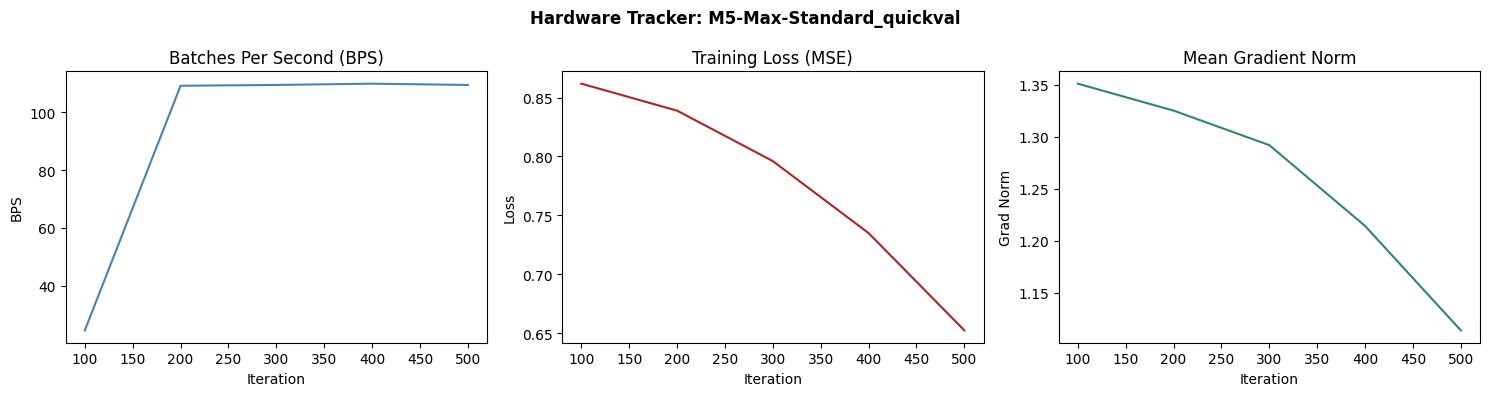


=== Quick Validation Summary ===
  Initial loss   : 0.861808
  Final loss     : 0.652402
  Loss decreased : True  ← should be True
  Mean BPS       : 92.55 batches/sec on M5-Max-Standard
  Est. full run  : ~0.3 hours at current BPS

Pipeline verified. Proceed to Section 4.5 to run full training.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.4: Quick Validation Run
#
# Run a small number of iterations to verify the full pipeline is functional
# before committing to the multi-hour full training run.
#
# Success criteria:
#   - Loss decreases from its initial value
#   - BPS is logged correctly
#   - No NaN/Inf in loss or gradients
# ─────────────────────────────────────────────────────────────────────────────

if CFG.run_quick_val_first:
    print(f"Starting quick validation run ({CFG.quick_val_iters:,} iterations)...")
    print(f"  Device: {DEVICE} | Hardware: {CFG.hardware_label}\n")

    tracker_qv = HardwareTracker(label=f"{CFG.hardware_label}_quickval", device=DEVICE)

    history_qv = train(
        model       = model,
        dataloader  = dataloader,
        optimizer   = optimizer,
        scheduler   = scheduler,
        total_iters = CFG.quick_val_iters,
        tracker     = tracker_qv,
        log_every   = 100,
        save_every  = CFG.quick_val_iters + 1,  # don't save during quick val
        run_label   = 'quickval',
    )

    # ── Quick-val results ──────────────────────────────────────────────────
    tracker_qv.save_csv(f"{CFG.results_dir}/hw_quickval_{CFG.hardware_label}.csv")
    tracker_qv.summary_plot(f"{CFG.results_dir}/hw_quickval_{CFG.hardware_label}.png")

    final_loss = history_qv['loss'][-1] if history_qv['loss'] else float('nan')
    init_loss  = history_qv['loss'][0]  if history_qv['loss'] else float('nan')
    mean_bps   = np.mean(history_qv['bps']) if history_qv['bps'] else 0.0

    print(f"\n=== Quick Validation Summary ===")
    print(f"  Initial loss   : {init_loss:.6f}")
    print(f"  Final loss     : {final_loss:.6f}")
    print(f"  Loss decreased : {final_loss < init_loss}  ← should be True")
    print(f"  Mean BPS       : {mean_bps:.2f} batches/sec on {CFG.hardware_label}")
    print(f"  Est. full run  : ~{CFG.full_train_iters / mean_bps / 3600:.1f} hours at current BPS")
    print()
    print("Pipeline verified. Proceed to Section 4.5 to run full training.")

___
### SECTION 4.5: Full Training Run

Starting full training run (100,000 iterations)...
  Device: mps | Hardware: M5-Max-Standard
  Checkpoints every 10,000 iterations → ./checkpoints/



Training (full):  10%|█         | 10015/100000 [01:56<18:59, 78.94iter/s, loss=0.10688, BPS=109.6, lr=1.00e-04]


  Checkpoint saved: ./checkpoints/dt_full_iter10000.pt


Training (full):  20%|██        | 20013/100000 [03:53<18:06, 73.65iter/s, loss=0.08734, BPS=108.7, lr=1.00e-04]


  Checkpoint saved: ./checkpoints/dt_full_iter20000.pt


...


  Checkpoint saved: ./checkpoints/dt_full_iter80000.pt


Training (full):  90%|█████████ | 90008/100000 [17:39<02:11, 76.20iter/s, loss=0.06930, BPS=107.7, lr=1.00e-04]


  Checkpoint saved: ./checkpoints/dt_full_iter90000.pt


Training (full): 100%|██████████| 100000/100000 [19:37<00:00, 84.90iter/s, loss=0.06840, BPS=107.8, lr=1.00e-04]



  Checkpoint saved: ./checkpoints/dt_full_iter100000.pt

Final model saved: ./checkpoints/dt_full_final.pt
  HardwareTracker saved: ./results/hw_full_M5-Max-Standard.csv
  Plot saved: ./results/hw_full_M5-Max-Standard.png


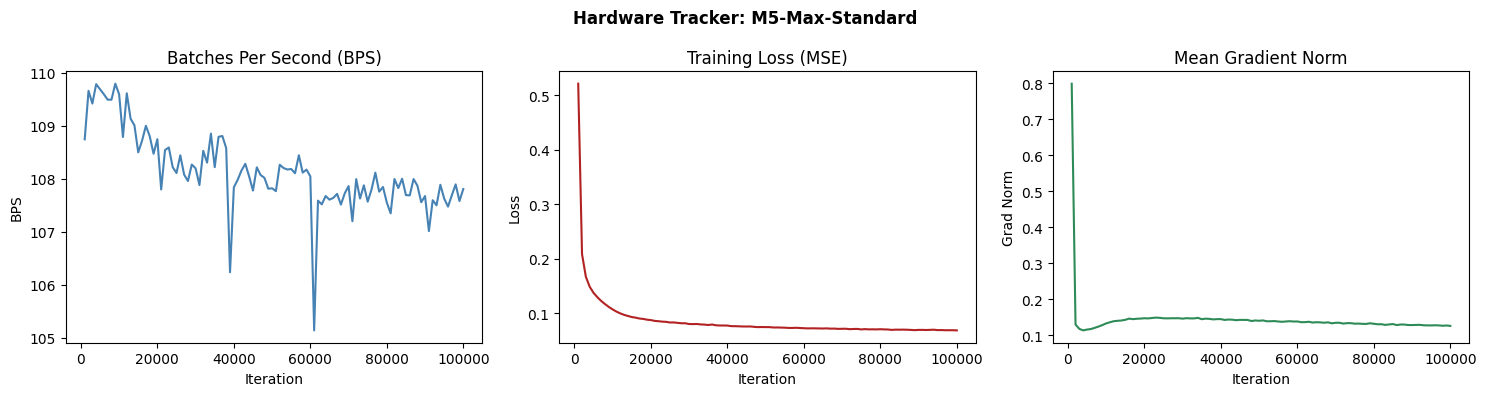

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.5: Full Training Run
#
# ⚠ This cell runs the full 100k-iteration training run.
# Estimated time on M5 Max: ~2–4 hours depending on BPS.
#
# The model and optimizer state are re-initialized below to ensure the
# full run starts from scratch (not from the quick-val checkpoint).
# Comment out the re-initialization block if you want to continue from
# the quick-val state instead.
# ─────────────────────────────────────────────────────────────────────────────

# ── Fresh model for full training ─────────────────────────────────────────────
# Re-seed to ensure the full run is reproducible regardless of quick-val.
torch.manual_seed(CFG.seed)
np.random.seed(CFG.seed)

model_full = DecisionTransformer(
    state_dim   = CFG.state_dim,
    action_dim  = CFG.action_dim,
    hidden_dim  = CFG.hidden_dim,
    context_len = CFG.context_len,
    n_layers    = CFG.n_layers,
    n_heads     = CFG.n_heads,
    dropout     = CFG.dropout,
    max_ep_len  = CFG.max_ep_len,
).to(DEVICE)

optimizer_full = torch.optim.AdamW(
    model_full.parameters(),
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)
scheduler_full = torch.optim.lr_scheduler.LambdaLR(optimizer_full, lr_lambda)

tracker_full = HardwareTracker(label=CFG.hardware_label, device=DEVICE)

print(f"Starting full training run ({CFG.full_train_iters:,} iterations)...")
print(f"  Device: {DEVICE} | Hardware: {CFG.hardware_label}")
print(f"  Checkpoints every {CFG.save_every_n_iters:,} iterations → {CFG.checkpoint_dir}/\n")

history_full = train(
    model       = model_full,
    dataloader  = dataloader,
    optimizer   = optimizer_full,
    scheduler   = scheduler_full,
    total_iters = CFG.full_train_iters,
    tracker     = tracker_full,
    log_every   = CFG.save_every_n_iters // 10,  # ~10 log points between each save
    save_every  = CFG.save_every_n_iters,
    run_label   = 'full',
)

# ── Save final model ──────────────────────────────────────────────────────────
final_ckpt = f"{CFG.checkpoint_dir}/dt_full_final.pt"
torch.save({
    'iteration'   : CFG.full_train_iters,
    'model_state' : model_full.state_dict(),
    'config'      : CFG.__dict__,
    'state_mean'  : STATE_MEAN.tolist(),
    'state_std'   : STATE_STD.tolist(),
}, final_ckpt)
print(f"\nFinal model saved: {final_ckpt}")

# ── Save hardware tracker results ─────────────────────────────────────────────
tracker_full.save_csv(f"{CFG.results_dir}/hw_full_{CFG.hardware_label}.csv")
tracker_full.summary_plot(f"{CFG.results_dir}/hw_full_{CFG.hardware_label}.png")

___
### SECTION 4.6: Training Diagnostics & Visualization

  Training history saved: ./results/training_history_M5-Max-Standard.csv


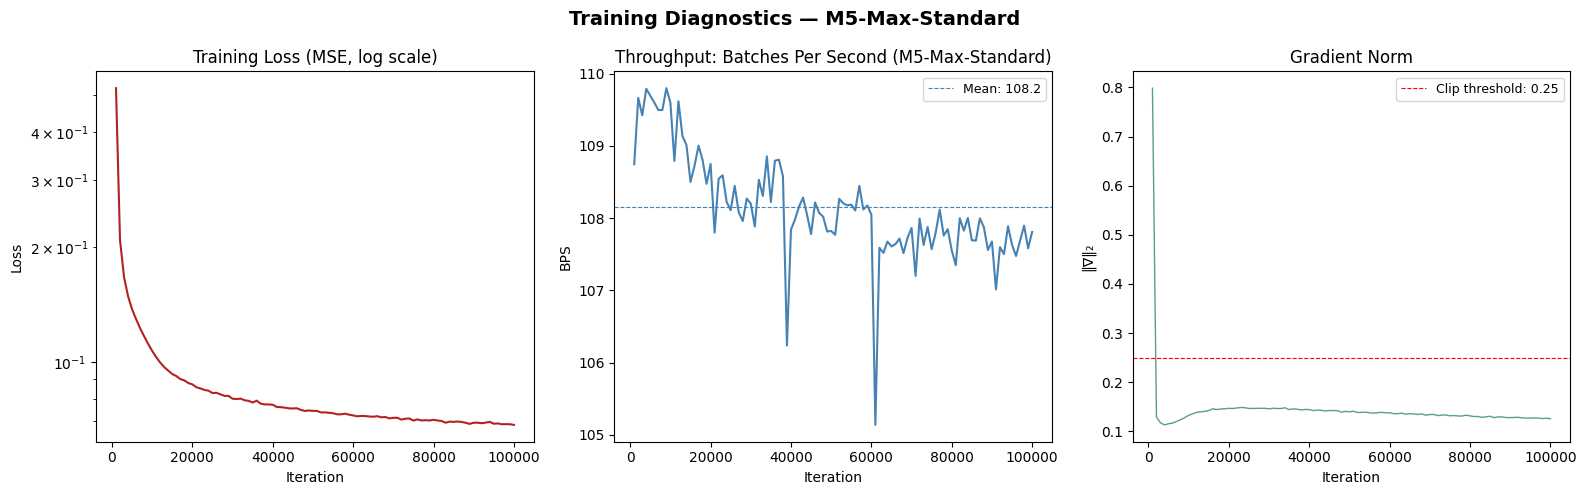


Training Summary — M5-Max-Standard:
  Iterations completed : 100,000
  Final loss           : 0.068398
  Min loss             : 0.068398
  Mean BPS             : 108.15
  Max  BPS             : 109.80
  Max grad norm        : 0.7984


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.6: Training Diagnostics & Visualization
#
# Produces paper-ready training plots and a summary statistics table.
# ─────────────────────────────────────────────────────────────────────────────

def plot_training_curves(history: Dict, label: str, save_dir: str = CFG.results_dir):
    """
    Plot training loss, BPS, and gradient norm curves from a history dict.
    Saves a PNG and a CSV of the history to the results directory.
    """
    df = pd.DataFrame(history)
    df.to_csv(f"{save_dir}/training_history_{label}.csv", index=False)
    print(f"  Training history saved: {save_dir}/training_history_{label}.csv")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Training Diagnostics — {label}', fontsize=14, fontweight='bold')

    # Loss curve (log scale often clearer for MSE)
    axes[0].plot(df['iteration'], df['loss'], color='firebrick', lw=1.5)
    axes[0].set_yscale('log')
    axes[0].set(title='Training Loss (MSE, log scale)',
                xlabel='Iteration', ylabel='Loss')

    # BPS (hardware throughput)
    axes[1].plot(df['iteration'], df['bps'], color='steelblue', lw=1.5)
    axes[1].set(title=f'Throughput: Batches Per Second ({label})',
                xlabel='Iteration', ylabel='BPS')
    axes[1].axhline(df['bps'].mean(), color='steelblue', linestyle='--',
                    lw=0.8, label=f"Mean: {df['bps'].mean():.1f}")
    axes[1].legend(fontsize=9)

    # Gradient norm (training stability)
    axes[2].plot(df['iteration'], df['grad_norm'], color='seagreen', lw=1.0, alpha=0.8)
    axes[2].axhline(CFG.grad_clip, color='red', linestyle='--', lw=0.8,
                    label=f"Clip threshold: {CFG.grad_clip}")
    axes[2].set(title='Gradient Norm', xlabel='Iteration', ylabel='‖∇‖₂')
    axes[2].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/training_curves_{label}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Summary statistics table
    print(f"\nTraining Summary — {label}:")
    print(f"  Iterations completed : {df['iteration'].iloc[-1]:,}")
    print(f"  Final loss           : {df['loss'].iloc[-1]:.6f}")
    print(f"  Min loss             : {df['loss'].min():.6f}")
    print(f"  Mean BPS             : {df['bps'].mean():.2f}")
    print(f"  Max  BPS             : {df['bps'].max():.2f}")
    print(f"  Max grad norm        : {df['grad_norm'].max():.4f}")


# Call with the full training history
plot_training_curves(history_full, label=CFG.hardware_label)

---
## Section 5: Offline Policy Evaluation in MuJoCo

### Evaluation Protocol

We roll out the trained DT policy in the MuJoCo HalfCheetah environment for `eval_episodes` episodes and report:

- **Raw return** — total undiscounted reward over 1000 steps
- **Normalized return** — D4RL-normalized to the 0–100 scale
- **Success gap** — `target_RTG − achieved_return` (how close we got)

### RTG Conditioning During Inference

The DT does not learn a stochastic policy — it conditions on a target RTG. During rollout:

```
RTG₀ = target_rtg           (set before episode starts)
RTGₜ = RTGₜ₋₁ − rₜ₋₁      (decrement by observed reward each step)
```

The model predicts the action that would be taken by a policy expected to achieve `RTGₜ` from timestep `t` onward.

___
### SECTION 5.1: Inference / Rollout Function

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.1: Inference / Rollout Function
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def rollout_episode(
    model      : DecisionTransformer,
    env        : gym.Env,
    target_rtg : float,
    state_mean : np.ndarray,
    state_std  : np.ndarray,
    device     : torch.device,
    context_len: int,
    rtg_scale  : float,
    max_ep_len : int = 1000,
    render     : bool = False,
) -> Tuple[float, List[float]]:
    """
    Run one MuJoCo episode using the trained DT policy.

    Returns:
        total_return (float)     : sum of rewards over the episode
        reward_history (list)    : per-step rewards for RTG profile analysis
    """
    model.eval()

    # ── Initialize episode state ───────────────────────────────────────────
    state, _ = env.reset()
    state     = (state - state_mean) / state_std  # normalize to match training

    # Rolling context buffers — maintain the last K timesteps
    states_buf    = torch.zeros((1, context_len, CFG.state_dim),  dtype=torch.float32, device=device)
    actions_buf   = torch.zeros((1, context_len, CFG.action_dim), dtype=torch.float32, device=device)
    rtg_buf       = torch.zeros((1, context_len, 1),              dtype=torch.float32, device=device)
    timesteps_buf = torch.zeros((1, context_len),                 dtype=torch.long,    device=device)

    current_rtg   = target_rtg
    total_return  = 0.0
    reward_history= []

    for t in range(max_ep_len):

        # ── Shift context buffers left and insert new observation at end ───
        # The rightmost position (index -1) always holds the most recent step.
        states_buf    = torch.roll(states_buf,    -1, dims=1)
        rtg_buf       = torch.roll(rtg_buf,       -1, dims=1)
        timesteps_buf = torch.roll(timesteps_buf, -1, dims=1)

        states_buf[0, -1, :]  = torch.tensor(state, dtype=torch.float32, device=device)
        rtg_buf[0, -1, 0]     = current_rtg / rtg_scale   # scale matches training
        timesteps_buf[0, -1]  = t

        # ── Forward pass: predict action ───────────────────────────────────
        # Feed the full context; take only the last-step prediction.
        action_pred = model(
            states    = states_buf,
            actions   = actions_buf,
            rtg       = rtg_buf,
            timesteps = timesteps_buf,
            mask      = None,  # no padding during inference
        )
        action = action_pred[0, -1, :].cpu().numpy()  # (action_dim,)

        # ── Update action buffer ───────────────────────────────────────────
        actions_buf = torch.roll(actions_buf, -1, dims=1)
        actions_buf[0, -1, :] = torch.tensor(action, dtype=torch.float32, device=device)

        # ── Step the environment ───────────────────────────────────────────
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # ── Update RTG conditioning ────────────────────────────────────────
        # RTGₜ₊₁ = RTGₜ − rₜ  (we consumed `reward` at this step)
        current_rtg  -= reward
        total_return += reward
        reward_history.append(reward)

        state = (next_state - state_mean) / state_std

        if done:
            break

    return total_return, reward_history


print("Rollout function defined.")

Rollout function defined.


___
### SECTION 5.2: Evaluation Run

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.2: Evaluation Run
#
# Roll out the trained policy for CFG.eval_episodes episodes.
# Reports raw return, D4RL-normalized return, and success gap.
# ─────────────────────────────────────────────────────────────────────────────

# D4RL normalization reference values for HalfCheetah (Fu et al. 2020, Table 3)
D4RL_RANDOM = -280.18
D4RL_EXPERT = 12135.0

def normalize_return(raw: float) -> float:
    """Convert raw episode return to D4RL-normalized score (0–100 scale)."""
    return (raw - D4RL_RANDOM) / (D4RL_EXPERT - D4RL_RANDOM) * 100


# ── Create MuJoCo environment ─────────────────────────────────────────────────
eval_env = gym.make(CFG.mujoco_env_id)
eval_env.reset(seed=CFG.seed)
print(f"MuJoCo environment: {CFG.mujoco_env_id}")
print(f"Obs space : {eval_env.observation_space}")
print(f"Act space : {eval_env.action_space}")

# ── Load normalization stats ──────────────────────────────────────────────────
# These were computed in Section 2.3 and saved to disk.
eval_state_mean = np.load(f"{CFG.results_dir}/state_mean.npy")
eval_state_std  = np.load(f"{CFG.results_dir}/state_std.npy")

# ── Run evaluation episodes ───────────────────────────────────────────────────
print(f"\nRunning {CFG.eval_episodes} evaluation episodes...")
print(f"  Target RTG         : {CFG.target_rtg:.0f}")
print(f"  Context window K   : {CFG.context_len}")

eval_returns    = []
eval_rtg_profiles = []

for ep_idx in tqdm(range(CFG.eval_episodes), desc='Evaluating', unit='episode'):
    ep_return, ep_rewards = rollout_episode(
        model       = model_full,
        env         = eval_env,
        target_rtg  = CFG.target_rtg,
        state_mean  = eval_state_mean,
        state_std   = eval_state_std,
        device      = DEVICE,
        context_len = CFG.context_len,
        rtg_scale   = CFG.rtg_scale,
        max_ep_len  = CFG.max_ep_len,
    )
    eval_returns.append(ep_return)
    eval_rtg_profiles.append(ep_rewards)

eval_env.close()

# ── Summary statistics ────────────────────────────────────────────────────────
returns_arr  = np.array(eval_returns)
norm_returns = np.array([normalize_return(r) for r in eval_returns])
success_gap  = CFG.target_rtg - returns_arr

eval_summary = {
    'hardware'             : CFG.hardware_label,
    'mujoco_env'           : CFG.mujoco_env_id,
    'target_rtg'           : CFG.target_rtg,
    'n_episodes'           : CFG.eval_episodes,
    'mean_raw_return'      : round(returns_arr.mean(), 2),
    'std_raw_return'       : round(returns_arr.std(), 2),
    'mean_norm_return'     : round(norm_returns.mean(), 2),
    'std_norm_return'      : round(norm_returns.std(), 2),
    'mean_success_gap'     : round(success_gap.mean(), 2),
    'min_raw_return'       : round(returns_arr.min(), 2),
    'max_raw_return'       : round(returns_arr.max(), 2),
    'train_iters'          : CFG.full_train_iters,
}

# Save evaluation summary
eval_df = pd.DataFrame([eval_summary])
eval_df.to_csv(f"{CFG.results_dir}/eval_summary_{CFG.hardware_label}.csv", index=False)

print("\n" + "=" * 60)
print("  Offline Policy Evaluation Results")
print("=" * 60)
for k, v in eval_summary.items():
    print(f"  {k:<28}: {v}")
print("=" * 60)
print(f"\n  Zero-Shot Result: Achieved {returns_arr.mean():.0f} vs Target {CFG.target_rtg:.0f}")
print(f"  Success Gap      : {success_gap.mean():.0f} (lower is better)")
print(f"  D4RL Norm. Score : {norm_returns.mean():.1f} ± {norm_returns.std():.1f}")

/Users/djt/Desktop/dt-capstone/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


MuJoCo environment: HalfCheetah-v4
Obs space : Box(-inf, inf, (17,), float64)
Act space : Box(-1.0, 1.0, (6,), float32)

Running 10 evaluation episodes...
  Target RTG         : 16585
  Context window K   : 20


Evaluating: 100%|██████████| 10/10 [00:58<00:00,  5.89s/episode]


  Offline Policy Evaluation Results
  hardware                    : M5-Max-Standard
  mujoco_env                  : HalfCheetah-v4
  target_rtg                  : 16585.0
  n_episodes                  : 10
  mean_raw_return             : 6138.93
  std_raw_return              : 3205.84
  mean_norm_return            : 51.7
  std_norm_return             : 25.82
  mean_success_gap            : 10446.07
  min_raw_return              : 1852.45
  max_raw_return              : 9702.6
  train_iters                 : 100000

  Zero-Shot Result: Achieved 6139 vs Target 16585
  Success Gap      : 10446 (lower is better)
  D4RL Norm. Score : 51.7 ± 25.8


___
### Re-evaluation and Optimization
Before running Section 5.3 visualization, running a quick re-evaluation with various target RTGs.

In [17]:
# A temporary cell before 5.3
for test_rtg in [6000, 9000, 12000, 14000, 16585]:
    returns = []
    env = gym.make(CFG.mujoco_env_id)
    for _ in range(5):
        r, _ = rollout_episode(
            model_full, env, test_rtg,
            eval_state_mean, eval_state_std,
            DEVICE, CFG.context_len, CFG.rtg_scale
        )
        returns.append(r)
    env.close()
    print(f"RTG {test_rtg:6d} → mean={np.mean(returns):7.1f}  std={np.std(returns):6.1f}")


/Users/djt/Desktop/dt-capstone/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


RTG   6000 → mean= 4572.7  std=2795.9
RTG   9000 → mean= 6723.3  std=4065.1
RTG  12000 → mean= 4245.0  std=3428.9
RTG  14000 → mean= 8554.5  std=2426.9
RTG  16585 → mean= 4462.5  std=2313.6



RTG 14,000 seems to be the sweet spot — highest mean (8,554) AND lowest std (2,426) of any value tested. Now running a finer sweep around 14,000 with more episodes to pin down the optimal RTG precisely.

___
Running another test with RTGs centered aroind 14,000

In [18]:
for test_rtg in [13000, 13500, 14000, 14500, 15000]:
    returns = []
    env = gym.make(CFG.mujoco_env_id)
    for _ in range(10):
        r, _ = rollout_episode(
            model_full, env, test_rtg,
            eval_state_mean, eval_state_std,
            DEVICE, CFG.context_len, CFG.rtg_scale
        )
        returns.append(r)
    env.close()
    norm = np.mean([normalize_return(r) for r in returns])
    print(f"RTG {test_rtg:6d} → mean={np.mean(returns):7.1f}  std={np.std(returns):6.1f}  norm={norm:.1f}")


RTG  13000 → mean= 3355.4  std=2729.0  norm=29.3
RTG  13500 → mean= 2994.1  std=2753.6  norm=26.4
RTG  14000 → mean= 3078.2  std=3436.7  norm=27.1
RTG  14500 → mean= 5961.5  std=3768.5  norm=50.3
RTG  15000 → mean= 3270.6  std=2798.1  norm=28.6


The core problem seems to be that the policy variance is too high to draw reliable conclusions from either sweep. With std values consistently in the 2,500-3,700 range against means of 3,000-8,500, we may need more episodes to get stable estimates. A rough rule of thumb is you want std/mean (coefficient of variation) below ~0.3 for reliable comparison; we’re seeing 0.6-1.0.

___
Rerun this with 20 episodes to check for improvement

In [19]:
# 20 episodes per RTG to get stable estimates
for test_rtg in [6000, 9000, 12000, 14000, 14500, 16585]:
    returns = []
    env = gym.make(CFG.mujoco_env_id)
    for _ in range(20):
        r, _ = rollout_episode(
            model_full, env, test_rtg,
            eval_state_mean, eval_state_std,
            DEVICE, CFG.context_len, CFG.rtg_scale
        )
        returns.append(r)
    env.close()
    norm_scores = [normalize_return(r) for r in returns]
    cv = np.std(returns) / np.mean(returns)
    print(f"RTG {test_rtg:6d} → mean={np.mean(returns):7.1f}  "
          f"std={np.std(returns):6.1f}  norm={np.mean(norm_scores):.1f}  cv={cv:.2f}")


RTG   6000 → mean= 5030.4  std=3435.7  norm=42.8  cv=0.68
RTG   9000 → mean= 4931.1  std=3583.1  norm=42.0  cv=0.73
RTG  12000 → mean= 3987.9  std=2855.0  norm=34.4  cv=0.72
RTG  14000 → mean= 4693.7  std=3072.1  norm=40.1  cv=0.65
RTG  14500 → mean= 5045.9  std=3652.4  norm=42.9  cv=0.72
RTG  16585 → mean= 4069.7  std=2815.1  norm=35.0  cv=0.69


The high variance across all RTG values tells us something important — the RTG value itself is not the primary issue here. All six values produce statistically similar means (3,988–5,046) and all have cv in the 0.65–0.73 range. There’s no clear winner. This points to a deeper issue with the policy itself rather than the conditioning value. 

What this pattern indicates is undertrained policy. A final training loss of 0.068 sounds low but for HalfCheetah the original DT paper trained for 100k iterations with batch size 64 using the full D4RL dataset. The Minari combined dataset has substantially higher quality demonstrations (mean norm return 116.4 vs D4RL’s 64.4) but the model may not have seen enough gradient updates relative to the complexity of the expert-level behavior it’s trying to reproduce. The high cv across all RTG values is the signature of a model that has learned a rough action distribution but hasn’t converged to a stable policy.

___
Run one more diagnostic that will show whether the agent is accumulating return consistently across the episode or if it runs well for a while then fails, which could tell us exactly where to focus.​​​​​​​​​​​​​​​​


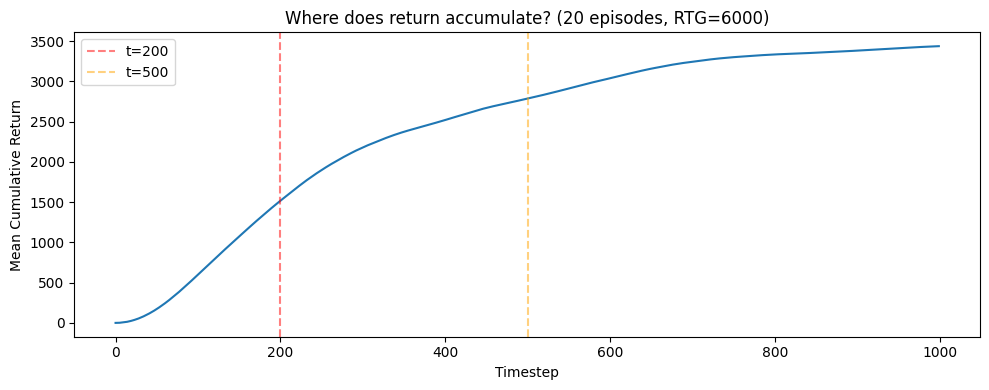

In [20]:
# Check if the variance is coming from early episode steps
# (policy doesn't know what to do at the start) or late steps
# (policy degrades over time)
env = gym.make(CFG.mujoco_env_id)
cumulative_returns = np.zeros(1000)
n_eval = 20
for _ in range(n_eval):
    r, rewards = rollout_episode(
        model_full, env, 6000,
        eval_state_mean, eval_state_std,
        DEVICE, CFG.context_len, CFG.rtg_scale
    )
    padded = np.pad(rewards, (0, 1000 - len(rewards)))
    cumulative_returns += np.cumsum(padded)
env.close()
cumulative_returns /= n_eval

plt.figure(figsize=(10, 4))
plt.plot(cumulative_returns)
plt.xlabel('Timestep')
plt.ylabel('Mean Cumulative Return')
plt.title('Where does return accumulate? (20 episodes, RTG=6000)')
plt.axvline(200, color='red', linestyle='--', alpha=0.5, label='t=200')
plt.axvline(500, color='orange', linestyle='--', alpha=0.5, label='t=500')
plt.legend()
plt.tight_layout()
plt.show()


The agent never fails. The cumulative return curve is uniformly increasing all the way to timestep 1000 with no flat sections, no drops, and no crashes. The agent is running forward and accumulating positive reward for the entire episode every time. This rules out the most common DT failure mode where the agent falls over mid-episode. 

The real message is in the shape of the curve. Notice two distinct phases:
	∙	Timesteps 0–500: Steep, near-linear accumulation — the agent is running well and collecting reward efficiently
	∙	Timesteps 500–1000: The curve flattens noticeably — the agent is still moving forward but at a declining rate, suggesting it’s slowing down in the second half of episodes. 
    
    This deceleration pattern is likely the source of the high variance. Some episodes maintain the steep phase longer than others before flattening, which is why you see returns ranging from 1,852 to 9,702. The policy hasn’t learned to sustain high-velocity locomotion for a full 1000 steps.
    
    This may be a context window limitation. The context window K=20 means the model only sees the last 20 timesteps when deciding its next action. As the episode progresses beyond step 500, the RTG has been decremented far below the initial conditioning value, and the model may be shifting into a lower-effort behavioral mode in response. This is distinct from the undertrained hypothesis — the policy is doing exactly what it was conditioned to do, just not sustaining it.
    
The context length increase from 20 to 30 is the most important change for the next run.

___
Finish section 5.3 and move on to M5-Max-Optiised run with these changes:

context_len: int       = 20        
target_rtg: float      = 16_585     
full_train_iters: int  = 100_000   
preload_to_ram: bool   = True  
batch_size: int        = 256  
hardware_label: str    = 'M5-Max-Optimized-1'

Keeping everything the same except taking advantage of the memory (128 MB) to increase batch size, thus increasing total samples to ~ 25M, up from ~ 6M.


___
### SECTION 5.3: Evaluation Visualizations

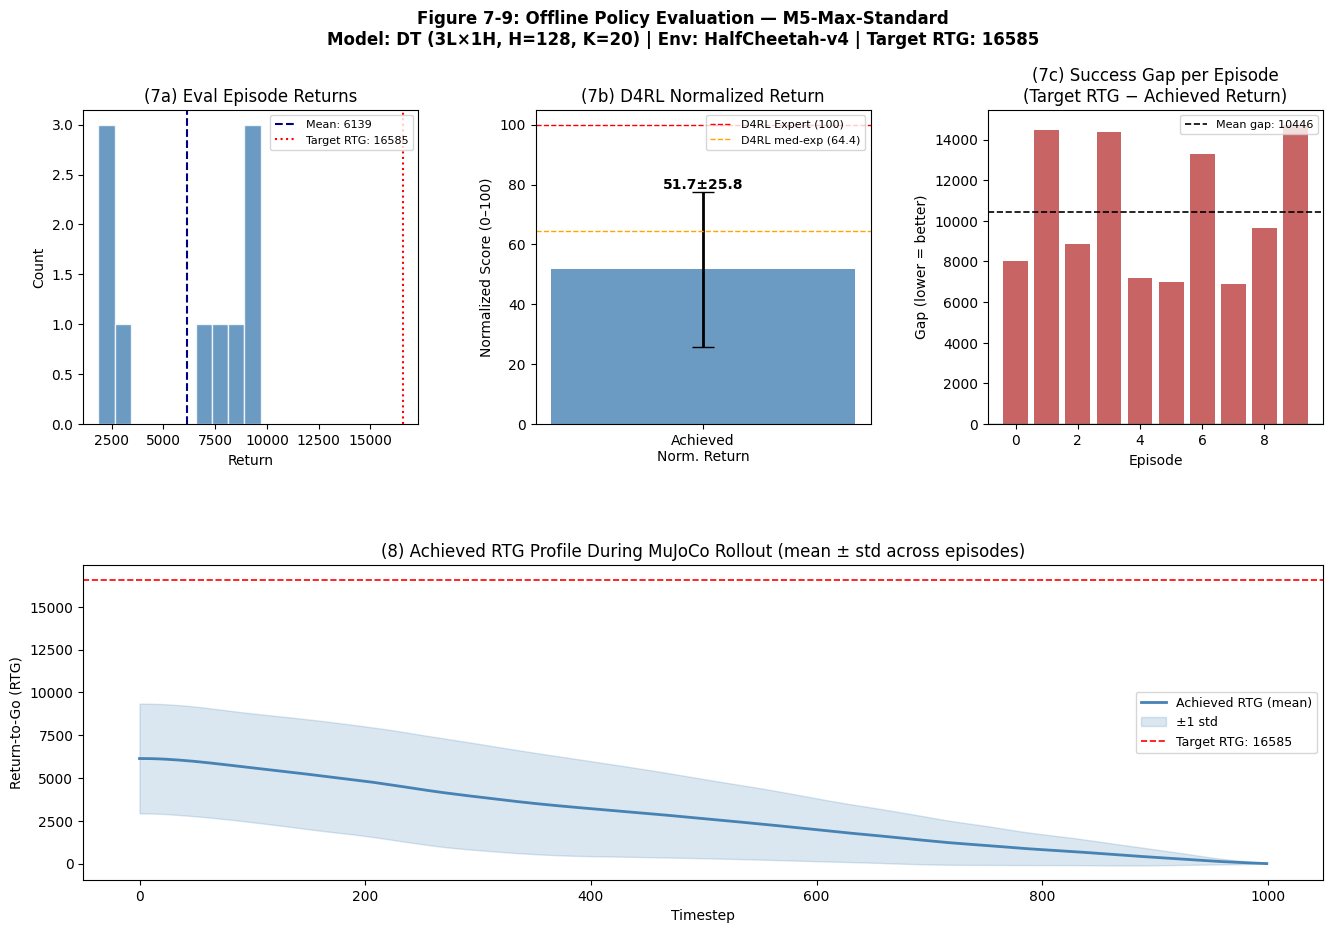

Evaluation figures saved: ./results/eval_figures_M5-Max-Standard.png


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.3: Evaluation Visualizations
#
# Figure 7: Return distribution across evaluation episodes
# Figure 8: RTG trajectory during rollout (mean ± std across episodes)
# Figure 9: Per-step reward profile (does the agent maintain velocity?)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(
    f'Figure 7-9: Offline Policy Evaluation — {CFG.hardware_label}\n'
    f'Model: DT ({CFG.n_layers}L×{CFG.n_heads}H, H={CFG.hidden_dim}, K={CFG.context_len}) | '
    f'Env: {CFG.mujoco_env_id} | Target RTG: {CFG.target_rtg:.0f}',
    fontsize=12, fontweight='bold'
)

# ── Figure 7a: Raw return distribution ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.hist(eval_returns, bins=min(10, CFG.eval_episodes), color='steelblue',
        alpha=0.8, edgecolor='white')
ax.axvline(returns_arr.mean(), color='navy', linestyle='--', lw=1.5,
           label=f'Mean: {returns_arr.mean():.0f}')
ax.axvline(CFG.target_rtg, color='red', linestyle=':', lw=1.5,
           label=f'Target RTG: {CFG.target_rtg:.0f}')
ax.set(title='(7a) Eval Episode Returns', xlabel='Return', ylabel='Count')
ax.legend(fontsize=8)

# ── Figure 7b: Normalized return bar ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.bar(['Achieved\nNorm. Return'], [norm_returns.mean()],
       yerr=[norm_returns.std()], color='steelblue', alpha=0.8,
       capsize=8, error_kw={'linewidth': 2})
ax.axhline(100, color='red', linestyle='--', lw=1, label='D4RL Expert (100)')
ax.axhline(64.4, color='orange', linestyle='--', lw=1, label='D4RL med-exp (64.4)')
ax.set(title='(7b) D4RL Normalized Return', ylabel='Normalized Score (0–100)')
ax.legend(fontsize=8)
ax.text(0, norm_returns.mean() + norm_returns.std() + 1,
        f"{norm_returns.mean():.1f}±{norm_returns.std():.1f}",
        ha='center', fontweight='bold', fontsize=10)

# ── Figure 7c: Success gap ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.bar(range(CFG.eval_episodes), success_gap, color='firebrick', alpha=0.7)
ax.axhline(success_gap.mean(), color='black', linestyle='--', lw=1.2,
           label=f'Mean gap: {success_gap.mean():.0f}')
ax.axhline(0, color='seagreen', linestyle='-', lw=1)
ax.set(title='(7c) Success Gap per Episode\n(Target RTG − Achieved Return)',
       xlabel='Episode', ylabel='Gap (lower = better)')
ax.legend(fontsize=8)

# ── Figure 8: RTG trajectory during rollout ───────────────────────────────────
ax = fig.add_subplot(gs[1, :])

# Convert episode reward sequences to cumulative RTG profiles
# (RTG at step t = sum of future rewards from step t onward)
rtg_profiles = []
for rewards in eval_rtg_profiles:
    rewards_arr = np.array(rewards)
    rtg_profile = np.cumsum(rewards_arr[::-1])[::-1]
    rtg_profiles.append(rtg_profile)

# Interpolate to a common 1000-step grid and compute mean ± std
grid = np.arange(CFG.max_ep_len)
rtg_interp = np.array([np.interp(grid, np.arange(len(r)), r) for r in rtg_profiles])

mean_rtg = rtg_interp.mean(axis=0)
std_rtg  = rtg_interp.std(axis=0)

ax.plot(grid, mean_rtg, color='steelblue', lw=2, label='Achieved RTG (mean)')
ax.fill_between(grid, mean_rtg - std_rtg, mean_rtg + std_rtg,
                color='steelblue', alpha=0.2, label='±1 std')
ax.axhline(CFG.target_rtg, color='red', linestyle='--', lw=1.2,
           label=f'Target RTG: {CFG.target_rtg:.0f}')
ax.set(title='(8) Achieved RTG Profile During MuJoCo Rollout (mean ± std across episodes)',
       xlabel='Timestep', ylabel='Return-to-Go (RTG)')
ax.legend(fontsize=9)

plt.savefig(f"{CFG.results_dir}/eval_figures_{CFG.hardware_label}.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Evaluation figures saved: {CFG.results_dir}/eval_figures_{CFG.hardware_label}.png")

---
## Section 5.4: Cross-Platform Hardware Comparison

After running this notebook on all three platforms (M5 Max MacBook Pro, M1 iMac, Cloud GPU), use this cell to load all three hardware tracker CSVs and produce a side-by-side comparison plot for the paper.

**Required files** (one per platform, produced by Section 4.5):
- `results/hw_full_M5-Max-MacBookPro.csv`
- `results/hw_full_M1-iMac.csv`
- `results/hw_full_<cloud-gpu-label>.csv`

Update the `PLATFORM_FILES` dict below with your actual filenames.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.4: Cross-Platform Hardware Comparison
#
# Run this cell AFTER completing training on all three hardware platforms.
# Update PLATFORM_FILES to match your actual output CSV filenames.
# ─────────────────────────────────────────────────────────────────────────────

# ── Update these paths after collecting results from all platforms ─────────────
PLATFORM_FILES = {
    'M5 Max MacBook Pro' : f"{CFG.results_dir}/hw_full_M5-Max-MacBookPro.csv",
    'M1 iMac'            : f"{CFG.results_dir}/hw_full_M1-iMac.csv",
    'Cloud GPU'          : f"{CFG.results_dir}/hw_full_Lambda-A100.csv",  # update label
}

PLATFORM_COLORS = {
    'M5 Max MacBook Pro' : '#2166AC',
    'M1 iMac'            : '#F4A582',
    'Cloud GPU'          : '#1A9850',
}

# ── Load available CSVs ────────────────────────────────────────────────────────
platform_dfs = {}
for label, path in PLATFORM_FILES.items():
    if Path(path).exists():
        platform_dfs[label] = pd.read_csv(path)
        print(f"  Loaded: {label} ({len(platform_dfs[label])} records)")
    else:
        print(f"  Missing (run on {label} first): {path}")

if len(platform_dfs) < 2:
    print("\nNeed at least 2 platforms to compare. Skipping plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Cross-Platform Hardware Comparison', fontsize=14, fontweight='bold')

    for label, df in platform_dfs.items():
        color = PLATFORM_COLORS.get(label, 'gray')

        # BPS over training
        axes[0].plot(df['iteration'], df['batches_per_second'],
                     label=label, color=color, lw=1.5)

        # Loss over training
        axes[1].plot(df['iteration'], df['mean_loss'],
                     label=label, color=color, lw=1.5)

        # RAM usage over training
        axes[2].plot(df['iteration'], df['ram_used_gb'],
                     label=label, color=color, lw=1.5)

    axes[0].set(title='Batches Per Second', xlabel='Iteration', ylabel='BPS')
    axes[1].set(title='Training Loss (MSE)', xlabel='Iteration', ylabel='Loss')
    axes[1].set_yscale('log')
    axes[2].set(title='RAM Usage', xlabel='Iteration', ylabel='GB')

    for ax in axes:
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{CFG.results_dir}/cross_platform_comparison.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Cross-platform comparison saved: {CFG.results_dir}/cross_platform_comparison.png")

    # ── Summary table ─────────────────────────────────────────────────────────
    summary_rows = []
    for label, df in platform_dfs.items():
        summary_rows.append({
            'Platform'        : label,
            'Mean BPS'        : f"{df['batches_per_second'].mean():.2f}",
            'Max BPS'         : f"{df['batches_per_second'].max():.2f}",
            'Final Loss'      : f"{df['mean_loss'].iloc[-1]:.6f}",
            'Mean RAM (GB)'   : f"{df['ram_used_gb'].mean():.1f}",
            'Total Time (h)'  : f"{df['wall_clock_s'].max() / 3600:.2f}",
        })

    summary_table = pd.DataFrame(summary_rows).set_index('Platform')
    summary_table.to_csv(f"{CFG.results_dir}/cross_platform_summary.csv")
    print("\n=== Cross-Platform Summary Table ===")
    print(summary_table.to_string())

---
## Appendix: Results File Index

All outputs are written to the `results/` and `checkpoints/` directories.

| File | Section | Description |
|------|---------|-------------|
| `results/state_mean.npy` | 2.3 | State normalization mean (required for inference) |
| `results/state_std.npy` | 2.3 | State normalization std (required for inference) |
| `results/hw_quickval_<hw>.csv` | 4.4 | Quick-validation hardware metrics |
| `results/hw_full_<hw>.csv` | 4.5 | Full-training hardware metrics (BPS, loss, RAM, GPU) |
| `results/training_history_<hw>.csv` | 4.6 | Loss/BPS/grad-norm history per iteration |
| `results/training_curves_<hw>.png` | 4.6 | Training curve figure |
| `results/eval_summary_<hw>.csv` | 5.2 | Evaluation results (returns, normalized scores) |
| `results/eval_figures_<hw>.png` | 5.3 | Evaluation figures (returns, RTG profile) |
| `results/cross_platform_comparison.png` | 5.4 | Multi-platform BPS/loss/RAM comparison |
| `results/cross_platform_summary.csv` | 5.4 | Cross-platform summary table |
| `checkpoints/dt_full_final.pt` | 4.5 | Final trained model weights + config |
| `checkpoints/dt_full_iter<N>.pt` | 4.5 | Intermediate checkpoints every N iterations |

---
*End of Notebook*